# 01 · Connectome tour

What the male CNS looks like as a graph, what the reservoir subgraph looks like, and how its eigenvalue spectrum compares to the control wirings.

Uses the real data if you've run `scripts/download_data.py`; otherwise it falls back to the synthetic stand-in and says so loudly.

In [2]:
from pathlib import Path
import os

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)  # configs and data paths are relative to the repo root

import numpy as np
import pandas as pd

from flyres import plotting
from flyres.connectome import FILES, cache_stem, load_connectome
from flyres.controls import make_wiring
from flyres.reservoir import scale_weights, signed_weights
from flyres.subgraph import graph_stats, select_subgraph
from flyres.synthetic import synthetic_connectome

RAW, CACHE, MIN_WEIGHT = Path("data/raw"), Path("data/cache"), 5
have_real = (CACHE / f"{cache_stem(MIN_WEIGHT)}.npz").exists() or all((RAW / f).exists() for f in FILES.values())
conn = load_connectome(RAW, CACHE, MIN_WEIGHT) if have_real else synthetic_connectome(n=3000, seed=0)
print("REAL male CNS v1.0" if have_real else "SYNTHETIC stand-in: download the data for the real thing")
conn.describe()

REAL male CNS v1.0


{'neurons': 166700,
 'edges': 6242085,
 'synapses': 89859936,
 'frac_inhibitory_neurons': 0.35782243551289744}

## Who's in there

In [3]:
conn.neurons["superclass"].value_counts().head(20)

superclass
ol_intrinsic          89403
cb_intrinsic          32164
vnc_intrinsic         13161
visual_projection      9201
vnc_sensory            6370
ol_sensory             6098
cb_sensory             4868
ascending_neuron       1846
descending_neuron      1314
vnc_motor               708
visual_centrifugal      563
sensory_ascending       537
cb_motor                107
vnc_efferent             94
cb_endocrine             72
ENS                      50
vnc_tbc                  38
vnc_sensory_tbc          36
vnc_endocrine            22
cb_sensory_tbc           14
Name: count, dtype: int64

In [4]:
# transmitter mix per superclass (the sign of each neuron's synapses comes from this)
mix = pd.crosstab(conn.neurons["superclass"], conn.neurons["nt"])
mix.loc[mix.sum(axis=1).sort_values(ascending=False).index].head(15)

nt,acetylcholine,dopamine,gaba,glutamate,histamine,octopamine,serotonin,unknown
superclass,,,,,,,,
ol_intrinsic,57719,0,10787,19043,1785,8,8,53
cb_intrinsic,19291,387,5008,6749,2,40,253,434
vnc_intrinsic,5547,0,5318,2106,2,7,14,167
visual_projection,8066,0,36,1003,0,0,1,95
vnc_sensory,5836,0,1,75,7,0,37,414
ol_sensory,0,0,0,0,6098,0,0,0
cb_sensory,4696,0,0,1,0,3,27,141
ascending_neuron,1272,0,407,128,4,0,21,14
descending_neuron,931,0,241,104,0,11,13,14


## Degree distribution

Heavy tails: most neurons have a modest number of partners, a few hubs have thousands. Random (Erdős–Rényi) graphs don't look like this at all, which is one reason the controls matter.

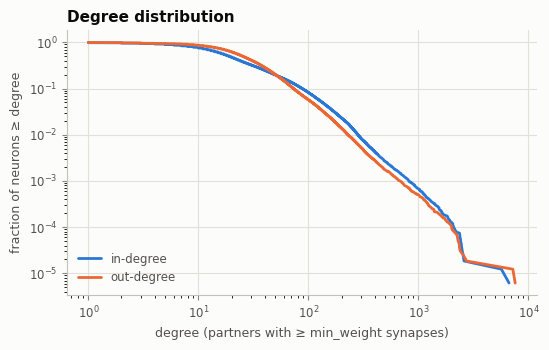

In [5]:
plotting.plot_degree_ccdf(conn.neurons);

## The reservoir subgraph

Grown from the 100 most-connected sensory neurons by repeatedly adding the neurons most strongly connected to the current set.

In [6]:
sub = select_subgraph(conn, n_neurons=3000, n_inputs=100, input_filter={"superclass": "sensory"})
cols = [c for c in ["superclass", "class", "type"] if c in sub.neurons.columns]
sub.neurons.loc[sub.input_idx, cols].value_counts().head(10)

subgraph: 3,000 neurons, 200,172 edges, 100 inputs, reciprocity 0.36, largest SCC 99%


superclass         class                          type    
cb_sensory         olfactory                      ORN_DP1m    20
                   thermosensory                  TRN_VP3a     6
vnc_sensory        mechanosensory_proprioceptive  SNpp32       6
                                                  SNpp30       6
                   unknown_sensory                SNxx29       5
cb_sensory         mechanosensory                 aPhM2a       4
                   gustatory                      PhG9         4
vnc_sensory        mechanosensory_tactile         SNta13       4
sensory_ascending  unknown_sensory                SAxx02       3
vnc_sensory        mechanosensory_proprioceptive  SNppxx       3
Name: count, dtype: int64

In [7]:
WIRINGS = ["connectome", "degree_preserving", "weight_shuffle", "sign_shuffle", "erdos_renyi"]
rows = []
for w in WIRINGS:
    Wc, s = make_wiring(w, sub.W, sub.sign, np.random.default_rng(0))
    rows.append({"wiring": w, **graph_stats(Wc, s)})
pd.DataFrame(rows).set_index("wiring").round(3)

,n,edges,density,reciprocity,largest_scc_frac,frac_inhibitory
wiring,,,,,,
connectome,3000,200172,0.022,0.360,0.990,0.36
degree_preserving,3000,200172,0.022,0.036,0.991,0.36
weight_shuffle,3000,200172,0.022,0.360,0.990,0.36
sign_shuffle,3000,200172,0.022,0.360,0.990,0.36
erdos_renyi,3000,200172,0.022,0.023,1.000,0.36


## Eigenvalue spectra at equal spectral radius

Every wiring is rescaled so its largest |eigenvalue| is 0.9 (the gray circle). What differs is where the rest of the spectrum sits: eigenvalues near the circle are slow modes (long memory), eigenvalues near zero die out fast. Dense eigendecomposition, so give it a minute at 3,000 neurons.

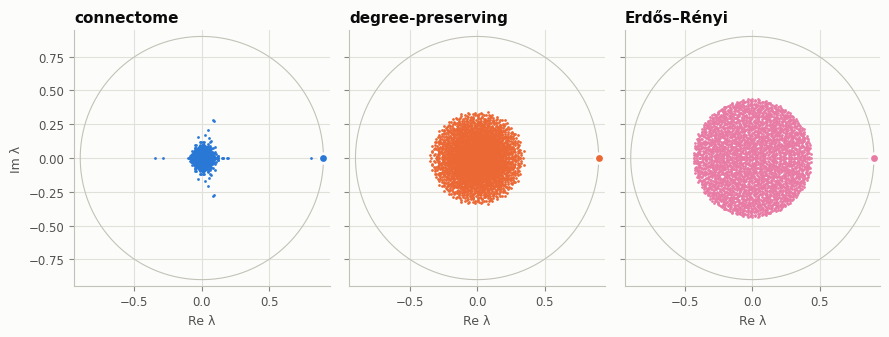

In [8]:
eigs = {}
for w in ["connectome", "degree_preserving", "erdos_renyi"]:
    Wc, s = make_wiring(w, sub.W, sub.sign, np.random.default_rng(0))
    W, _ = scale_weights(signed_weights(Wc, s, "log1p"), 0.9)
    eigs[w] = np.linalg.eigvals(W.toarray().astype(np.float64))
plotting.plot_spectra(eigs, radius=0.9);

In [9]:
pd.DataFrame({w: {"share |λ| > 0.5": (np.abs(e) > 0.5).mean(),
                  "share |λ| > 0.2": (np.abs(e) > 0.2).mean(),
                  "median |λ|": np.median(np.abs(e))} for w, e in eigs.items()}).T.round(3)

,share |λ| > 0.5,share |λ| > 0.2,median |λ|
connectome,0.001,0.003,0.031
degree_preserving,0.000,0.410,0.176
erdos_renyi,0.000,0.784,0.306
